In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
!pip install pandas numpy matplotlib scikit-learn openpyxl

In [38]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive (24)\train.csv")

In [39]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [41]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [42]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [43]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [44]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df = df.sort_values("Order Date")
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.strftime("%b %Y")

print(monthly_sales)

   Order Date        Sales
0    Jan 2015   14205.7070
1    Feb 2015    4519.8920
2    Mar 2015   55205.7970
3    Apr 2015   27906.8550
4    May 2015   23644.3030
5    Jun 2015   34322.9356
6    Jul 2015   33781.5430
7    Aug 2015   27117.5365
8    Sep 2015   81623.5268
9    Oct 2015   31453.3930
10   Nov 2015   77907.6607
11   Dec 2015   68167.0585
12   Jan 2016   18066.9576
13   Feb 2016   11951.4110
14   Mar 2016   32339.3184
15   Apr 2016   34154.4685
16   May 2016   29959.5305
17   Jun 2016   23599.3740
18   Jul 2016   28608.2590
19   Aug 2016   36818.3422
20   Sep 2016   63133.6060
21   Oct 2016   31011.7375
22   Nov 2016   75249.3995
23   Dec 2016   74543.6012
24   Jan 2017   18542.4910
25   Feb 2017   22978.8150
26   Mar 2017   51165.0590
27   Apr 2017   38679.7670
28   May 2017   56656.9080
29   Jun 2017   39724.4860
30   Jul 2017   38320.7830
31   Aug 2017   30542.2003
32   Sep 2017   69193.3909
33   Oct 2017   59583.0330
34   Nov 2017   79066.4958
35   Dec 2017   95739.1210
3

In [57]:
df.duplicated().sum()

np.int64(0)

In [59]:
df = df.drop_duplicates()

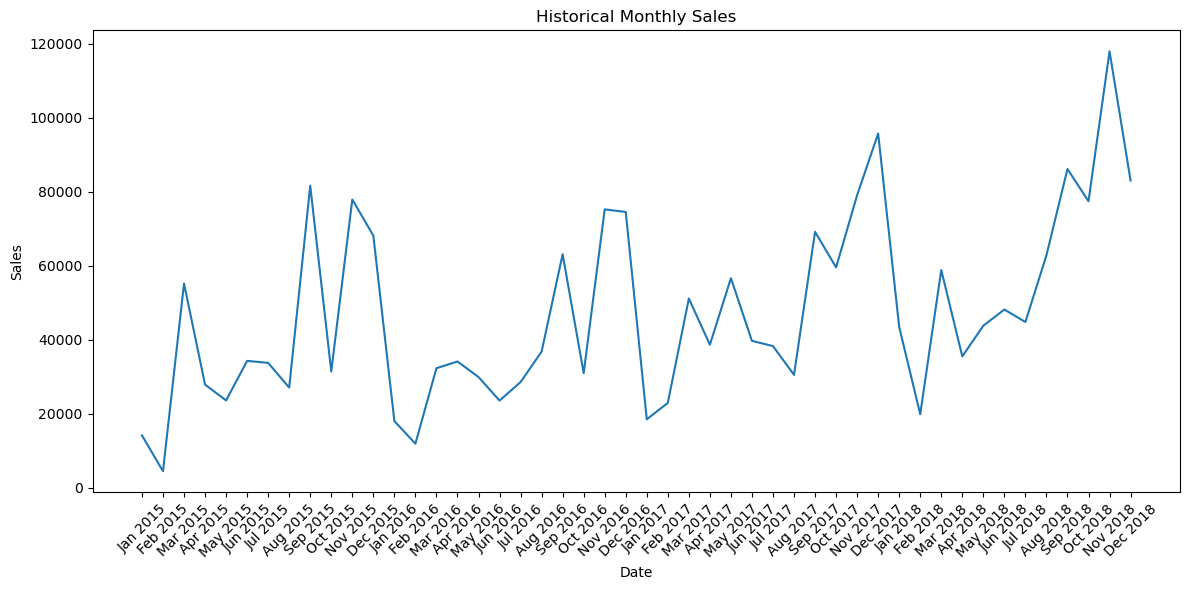

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)

plt.title("Historical Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [46]:
monthly_sales["Time"] = np.arange(len(monthly_sales))
X = monthly_sales[["Time"]]
y = monthly_sales["Sales"]


In [47]:
split_point = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

In [48]:
model = LinearRegression()

In [49]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred = model.predict(X_test)

In [51]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head()

,Actual Sales,Predicted Sales
0,58863.4128,55563.601236
1,35541.9101,56249.882764
2,43825.9822,56936.164291
3,48190.7277,57622.445819
4,44825.1040,58308.727347


In [52]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 18560.28591345771


In [29]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 23619.289223453263


In [53]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.03323365449775528


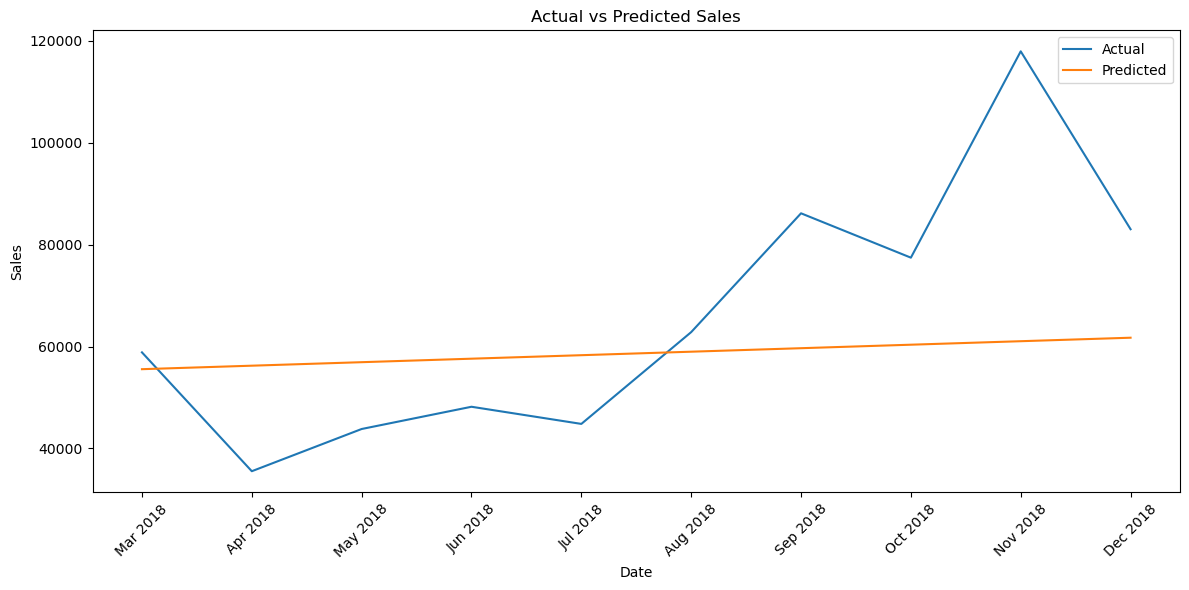

In [54]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"].iloc[split_point:],
    y_test.values,
    label="Actual"
)

plt.plot(
    monthly_sales["Order Date"].iloc[split_point:],
    y_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [55]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

last_date = monthly_sales["Order Date"].max()

future_time = np.arange(
    len(monthly_sales),
    len(monthly_sales) + 6
).reshape(-1, 1)

future_predictions = model.predict(future_time)

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=6,
    freq="ME"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Sales": future_predictions
})

monthly_sales["Order Date Display"] = monthly_sales["Order Date"].dt.strftime("%b %Y")
future_df["Date Display"] = future_df["Date"].dt.strftime("%b %Y")

print(future_df)


        Date  Predicted Sales Date Display
0 2019-01-31     62426.416513     Jan 2019
1 2019-02-28     63112.698041     Feb 2019
2 2019-03-31     63798.979569     Mar 2019
3 2019-04-30     64485.261097     Apr 2019
4 2019-05-31     65171.542624     May 2019
5 2019-06-30     65857.824152     Jun 2019


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


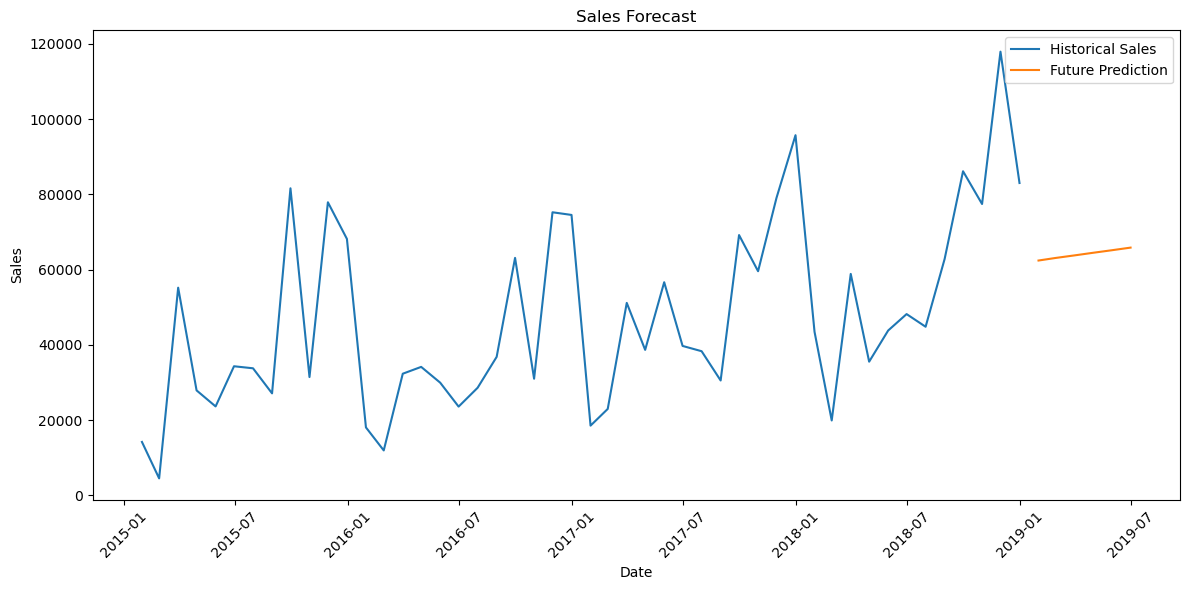

In [56]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_df["Date"],
    future_df["Predicted Sales"],
    label="Future Prediction"
)

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()